In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [3]:
df=pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [4]:
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
10761,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
37800,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
39290,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11682,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9793,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
import matplotlib.pyplot as plt

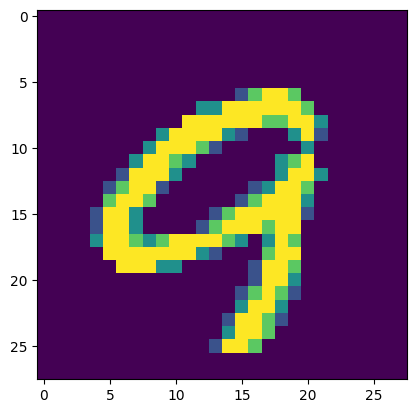

In [6]:
plt.imshow(df.iloc[9793,1:].values.reshape(28,28))

In [42]:
x=df.iloc[:,1:]
y=df.iloc[:,0]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) 


In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
knn=KNeighborsClassifier()

In [45]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [46]:
y_pred=knn.predict(x_test)

In [47]:
y_pred

array([8, 1, 9, ..., 3, 0, 9])

In [48]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.9648809523809524

In [49]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [50]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [51]:
from sklearn.decomposition import PCA
pca=PCA(n_components=100)

In [52]:
x_train_trf=pca.fit_transform(x_train)
x_test_trf=pca.transform(x_test)

In [53]:
x_train_trf.shape

(33600, 100)

In [55]:
knn.fit(x_train_trf,y_train)

KNeighborsClassifier()

In [57]:
ypred=knn.predict(x_test_trf)

In [60]:
accuracy_score(y_test,ypred)

0.955595238095238